<a href="https://colab.research.google.com/github/alscop/ESAA-26-1/blob/main/0313_%EC%84%B8%EC%85%98_%EB%B9%84%EC%A7%80%EB%8F%84%ED%95%99%EC%8A%B5_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [1]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___

1. 엘보우 기법: k를 1부터 차례대로 늘려가며 각 데이터 지점과 해당 군집의 중심점(Centroid) 사이의 거리를 제곱해서 합산한 값의 변화를 그래프로 그림. 값이 급격히 감소하다가 어느순간부터 감소 폭이 완만해지는 지점이 생김. 그 지점의 k가 최적값이며, 그래프의 모습이 팔꿈치같다고 해서 엘보우기법.
2. 실루엣 분석: 엘보우기법보다 정교함.(단순히 거리 합만 보는게 아니라, 군집간 거리까지 고려하기때문) 군집 안의 데이터들이 얼마나 촘촘하게 모여 있고 다른 군집과는 얼마나 떨어져 있는지를 수치화. -1부터1까지의 '실루엣계수'를 사용함.
- 1에 가까울수록: 자신의 군집과 잘 어울리고 다른 군집과는 멀리 떨어져 있다
- 0에 가까울수록: 군집 경계에 데이터가 위치한다
- -1에 가까울수록: 데이터가 잘못된 군집에 할당되었다  

모든 데이터의 평균 실루엣 계수가 가장 높으면서, 동시에 개별 군집별 실루엣 계수가 고르게 높은 k를 선택

### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___

1. 대규모 데이터셋으로 확장할 수 있는 알고리즘
- 미니배치 k-평균 (Mini-batch k-means)
  - 전체 데이터를 한 번에 처리하지 않고, 데이터를 작은 묶음(Mini-batch)으로 나누어 조금씩 업데이트하며 중심점을 찾아가는 방식
  - 일반 k-평균보다 속도가 훨씬 빠르고 메모리 사용량이 적어 대규모 데이터에 적합
- BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)
  - 대규모 데이터셋을 위해 설계된 알고리즘으로, 데이터를 읽으면서 요약된 정보를 담은 '클러스터링 특징 트리'를 구축
  - 전체 데이터를 메모리에 다 올리지 않고도 효율적으로 군집화 수행 가능

2. 밀도가 높은 지역을 찾는(밀도 기반) 알고리즘
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
  - 가장 대표적인 밀도 기반 알고리즘
  - 특정 반경 내에 최소 몇 개의 데이터가 있는지 확인하여 밀도가 높은 지역을 군집으로 묶음.
  - 군집에 속하지 않는 데이터를 '노이즈(이상치)'로 구분해내는 능력이 탁월
- OPTICS (Ordering Points To Identify the Clustering Structure)
  - DBSCAN과 유사하지만, 데이터의 밀도가 일정하지 않은 경우(어떤 곳은 촘촘하고 어떤 곳은 널널할 때)에도 더 유연하게 군집을 찾아낼 수 있도록 개선된 알고리즘

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___

가우시안혼합(GMM): k-평균보다 훨씬 유연한 '확률적' 군집 알고리즘.  
데이터가 여러 개의 가우시안 분포(정규 분포)가 섞여서 생성되었다고 가정하는 확률 모델
- 작동 원리: 전체 데이터 세트 안에 여러 개의 정규 분포가 숨어 있다고 보고, 각 데이터가 어떤 분포에서 나왔을 확률이 높은지를 계산
- k-평균과의 차이
  - k-평균
    - 데이터를 무조건 하나의 군집에 할당(Hard Clustering)
    - 원형으로만 묶음
  - GMM
    - 데이터가 각 군집에 속할 확률을 제공(Soft Clustering)
    - 타원형처럼 길쭉한 모양의 군집도 잘 찾아내는 편

따라서, 단순 군집화를 넘어 통계적 특성 활용한 다양한 작업에 쓰임.
- 군집화: 데이터가 타원형 분포일때 / 크기가 서로 다른 군집이 섞여있을 때
- 이상치 탐지: 모델이 학습한 가우시안 분포에서 발생할 확률이 매우 낮은(밀도가 낮은) 지역에 위치한 데이터를 이상치로 판별합니다. (예: 공정 불량 탐지, 금융 사기 적발)
- 밀도 추정: 데이터의 전체적인 확률 분포 모양을 추정하여, 데이터가 어디에 많이 모여 있고 어디에 적게 있는지 파악
- 데이터 생성: 학습된 분포를 바탕으로 새로운 가짜 데이터를 생성(Sampling)도 가능



### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.




#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [2]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# 전체 데이터를 훈련:나머지 8:2로 분리
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, temp_index in split.split(olivetti.data, olivetti.target):
    X_train = olivetti.data[train_index]
    y_train = olivetti.target[train_index]
    X_temp = olivetti.data[temp_index]
    y_temp = olivetti.target[temp_index]

# 남은 20%를 다시 검증 세트(10%)와 테스트 세트(10%)로 분리.
split_temp = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)

for val_index, test_index in split_temp.split(X_temp, y_temp):
    X_val = X_temp[val_index]
    y_val = y_temp[val_index]
    X_test = X_temp[test_index]
    y_test = y_temp[test_index]

# 결과 확인
print(f"훈련 세트 크기: {X_train.shape}")
print(f"검증 세트 크기: {X_val.shape}")
print(f"테스트 세트 크기: {X_test.shape}")

훈련 세트 크기: (320, 4096)
검증 세트 크기: (40, 4096)
테스트 세트 크기: (40, 4096)


한 사람당 사진이 10장밖에 없어서 ...   
train_test_split으로 무작위로 섞어서 나누면 훈련/검증 세트 중 한쪽에만 전부 들어갈 수도 있음.  
계층적샘플링 이용해 사진 10장을 비율에 맞춰 8장(훈련), 1장(검증), 1장(테스트)씩 정확히 배분

####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다. : 전체 분산(변동성)을 99%로 유지

In [5]:
from sklearn.decomposition import PCA

# 분산의 99%를 유지하는 PCA 모델 생성
pca = PCA(n_components=0.99, random_state=42)

# 훈련 세트로 PCA 학습 및 변환
X_train_pca = pca.fit_transform(X_train)

# 검증 및 테스트 세트는 '변환'만 수행
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# 차원 축소 결과 확인
print(f"원본 피처 개수: {X_train.shape[1]}")
print(f"축소된 피처 개수: {X_train_pca.shape[1]}")
print(f"설명된 분산 비율 합계: {pca.explained_variance_ratio_.sum():.4f}")

원본 피처 개수: 4096
축소된 피처 개수: 222
설명된 분산 비율 합계: 0.9901


####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
# k 후보 범위 설정 (예: 5개 단위로 5~150까지)
k_range = range(5, 151, 5)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)

    inertias.append(kmeans.inertia_)
    # 실루엣 점수는 계산 시간이 다소 소요될 수 있습니다.
    score = silhouette_score(X_train_pca, kmeans.labels_)
    silhouette_scores.append(score)

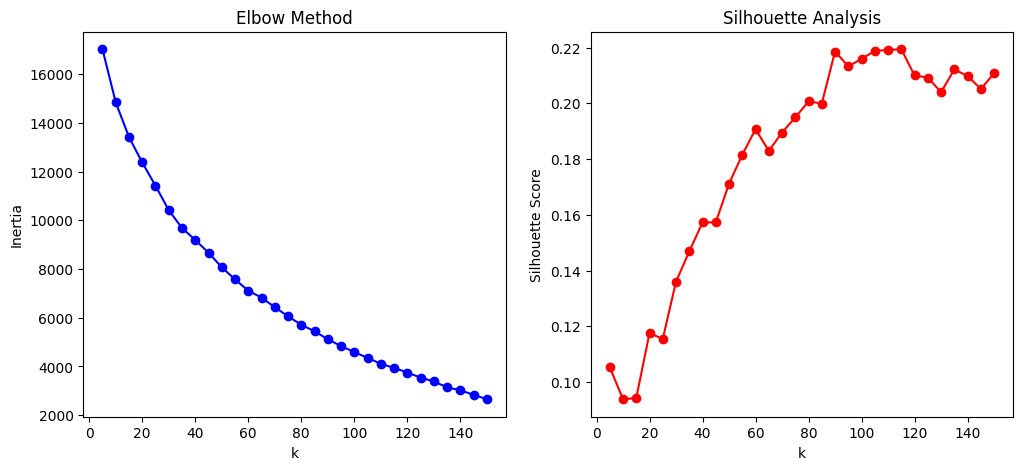

In [9]:
# 결과 시각화
plt.figure(figsize=(12, 5))

# 엘보우 그래프
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, "bo-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# 실루엣 점수 그래프
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, "ro-")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

ㅠㅠ 엘보우 그래프로는 파악 어려움  
실루엣 계수는 90보다 찌끔 큰 듯?!  


In [10]:
# 그래프를 보고 판단한 최적의 k로 최종 군집화 (예: 실루엣 점수가 높은 지점)
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"최적의 클러스터 개수(실루엣 기준): {best_k}")

best_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
best_kmeans.fit(X_train_pca)

최적의 클러스터 개수(실루엣 기준): 115


KMeans(n_clusters=115, n_init=10, random_state=42)

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [11]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

--- Cluster 0 (Total: 2 faces) ---


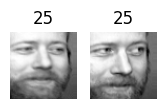

--- Cluster 1 (Total: 2 faces) ---


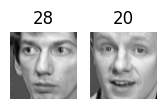

--- Cluster 2 (Total: 1 faces) ---


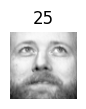

--- Cluster 3 (Total: 2 faces) ---


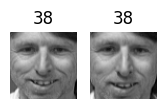

--- Cluster 4 (Total: 4 faces) ---


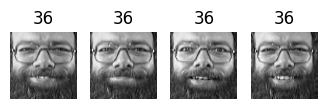

In [12]:
# 시각화할 클러스터의 개수를 지정. 앞선 5개 군집만 확인
n_clusters_to_plot = 5

for cluster_id in range(n_clusters_to_plot):
    # 해당 클러스터에 속한 데이터의 인덱스 탐색.
    in_cluster = (best_kmeans.labels_ == cluster_id)
    faces_in_cluster = X_train[in_cluster]
    labels_in_cluster = y_train[in_cluster] # 실제 사람 ID (정답)

    print(f"--- Cluster {cluster_id} (Total: {len(faces_in_cluster)} faces) ---")

    # 해당 클러스터에 데이터가 있다면 시각화.
    if len(faces_in_cluster) > 0:
        plot_faces(faces_in_cluster, labels_in_cluster)
    else:
        print("이 클러스터에는 할당된 얼굴이 없습니다.")